# Clustering analysis — GDP projections

Compare final populations from the paired local runs:

| Method | Output dir |
|---|---|
| Leader–Follower | `data/outputs/local_20261007_162107_lf_g210` |
| IncDBSCAN | `data/outputs/local_20261007_162107_inc_dbscan_g210` |

Visualization uses **Genetic Distance Projection (GDP)** via `utils.gdp_projection`:
- **MDS-GDP** on prompt embeddings (cosine distances)
- 2D species coloring
- 3D: MDS × MDS × toxicity (alive colored by species; archive dark)
- 3D: MDS × MDS × generation (color = toxicity)
- Interactive Plotly HTML for exploration

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
GDP_ROOT = PROJECT_ROOT / "genetic-distance-projection-main"
if not GDP_ROOT.exists():
    # Fallback: sibling AMBER checkout used during local development
    alt = Path("/Users/onkars/Documents/Projects/AMBER/genetic-distance-projection-main")
    if alt.exists():
        GDP_ROOT = alt

for p in (str(SRC), str(GDP_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)

from utils.gdp_projection import (
    DEFAULT_VIEW_ANGLES,
    build_genome_data_from_elites_archive,
    generate_gdp_3d_generation_axis_toxicity_color,
    generate_gdp_3d_plotly_generation_axis_toxicity_color,
    generate_gdp_3d_plotly_toxicity_figure,
    generate_gdp_3d_toxicity_figure,
    generate_gdp_figure,
    get_gdp_import_error,
    is_gdp_available,
    run_gdp_projection,
)
from utils.population_io import _extract_north_star_score

assert is_gdp_available(), f"GDP unavailable: {get_gdp_import_error()}"
print("Project:", PROJECT_ROOT)
print("GDP:", GDP_ROOT, "available=", is_gdp_available())

Project: /Users/onkars/Documents/Projects/ToxSearch-S
GDP: /Users/onkars/Documents/Projects/ToxSearch-S/genetic-distance-projection-main available= True


In [2]:
RUNS = {
    "Leader–Follower": PROJECT_ROOT / "data/outputs/local_20261007_162107_lf_g210",
    "IncDBSCAN": PROJECT_ROOT / "data/outputs/local_20261007_162107_inc_dbscan_g210",
}

NORTH_STAR = "toxicity"


def population_paths(run_dir: Path):
    """L–F uses elites+archive; IncDBSCAN uses density memory temp.json."""
    elites = run_dir / "elites.json"
    archive = run_dir / "archive.json"
    temp = run_dir / "temp.json"
    if temp.exists() and temp.stat().st_size > 4 and (
        not elites.exists() or elites.stat().st_size <= 4
    ):
        return temp, None
    return elites, archive if archive.exists() else None


def summarize(name: str, run_dir: Path):
    elites_path, archive_path = population_paths(run_dir)
    _, genomes, _ = build_genome_data_from_elites_archive(elites_path, archive_path)
    scores = [_extract_north_star_score(g, NORTH_STAR) for g in genomes]
    species = [g.get("species_id", g.get("density_label")) for g in genomes]
    n_species = len({s for s in species if s is not None and int(s) > 0})
    n_noise = sum(1 for s in species if s is None or int(s) <= 0)
    return {
        "name": name,
        "dir": run_dir.name,
        "source": elites_path.name + (f" + {archive_path.name}" if archive_path else ""),
        "n": len(genomes),
        "n_species": n_species,
        "n_noise_or_archive": n_noise,
        "tox_mean": float(sum(scores) / len(scores)) if scores else 0.0,
        "tox_max": float(max(scores)) if scores else 0.0,
        "gen_max": max((int(g.get("generation", 0)) for g in genomes), default=0),
        "genomes": genomes,
        "elites_path": elites_path,
        "archive_path": archive_path,
    }


summaries = {name: summarize(name, d) for name, d in RUNS.items()}
for s in summaries.values():
    print(
        f"{s['name']}: n={s['n']} | source={s['source']} | "
        f"species={s['n_species']} noise/neg={s['n_noise_or_archive']} | "
        f"tox mean={s['tox_mean']:.4f} max={s['tox_max']:.4f} | max_gen={s['gen_max']}"
    )

Leader–Follower: n=210 | source=elites.json + archive.json | species=39 noise/neg=87 | tox mean=0.0453 max=0.1827 | max_gen=23
IncDBSCAN: n=210 | source=temp.json | species=23 noise/neg=0 | tox mean=0.0391 max=0.2705 | max_gen=26


## Run MDS-GDP and write figures

Figures are saved under each run’s `figures/gdp_notebook/` directory and displayed below.

Saved figure to /Users/onkars/Documents/Projects/ToxSearch-S/data/outputs/local_20261007_162107_lf_g210/figures/gdp_notebook/gdp_2d_species.png


/Users/onkars/Documents/Projects/ToxSearch-S/src/utils/gdp_projection.py:518: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


/Users/onkars/Documents/Projects/ToxSearch-S/src/utils/gdp_projection.py:643: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Leader–Follower n= 210 ok= {'2d': True, '3d_sa': True, '3d_gen': True, 'plotly_tox': True, 'plotly_gen': True}


Saved figure to /Users/onkars/Documents/Projects/ToxSearch-S/data/outputs/local_20261007_162107_inc_dbscan_g210/figures/gdp_notebook/gdp_2d_species.png


/Users/onkars/Documents/Projects/ToxSearch-S/src/utils/gdp_projection.py:643: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



IncDBSCAN n= 210 ok= {'2d': True, '3d_sa': True, '3d_gen': True, 'plotly_tox': True, 'plotly_gen': True}


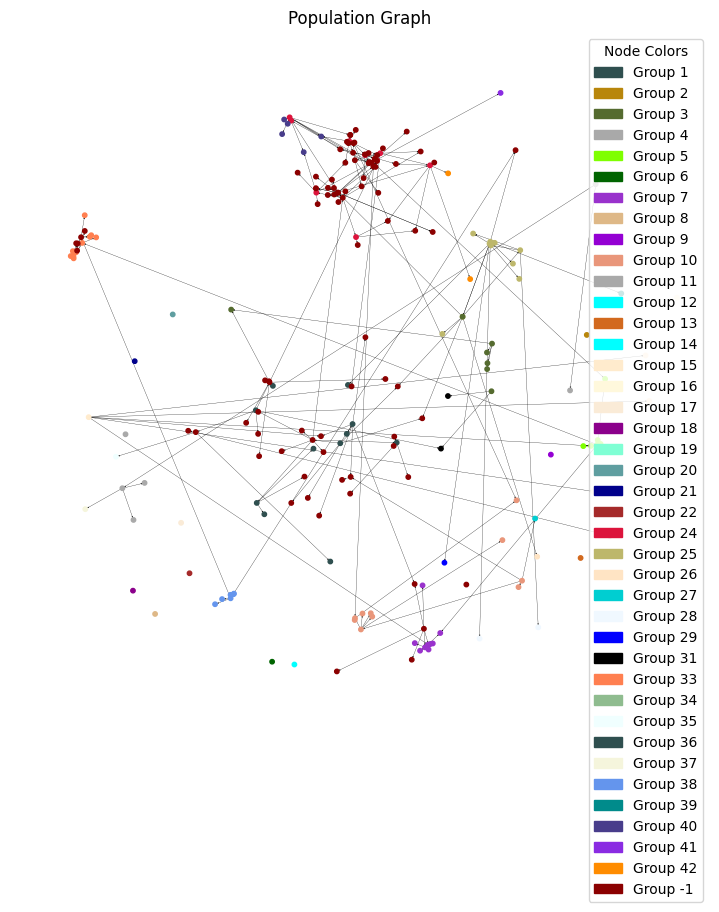

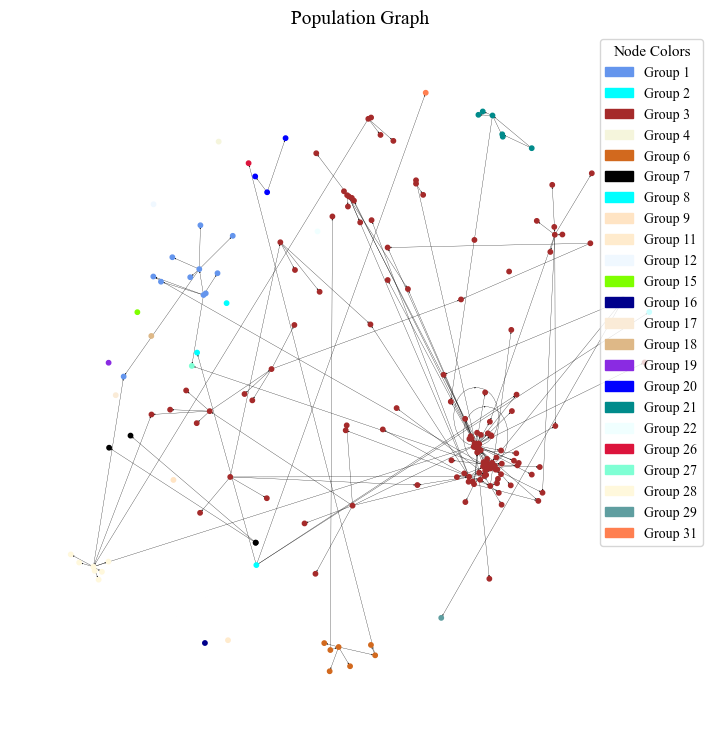

In [3]:
results = {}

for name, s in summaries.items():
    out_dir = RUNS[name] / "figures" / "gdp_notebook"
    out_dir.mkdir(parents=True, exist_ok=True)

    payload, reduced = run_gdp_projection(
        elites_path=s["elites_path"],
        output_dir=out_dir,
        archive_path=s["archive_path"],
        reduced_size=2,
        save_json=True,
        random_state=42,
    )
    assert reduced is not None, f"GDP reduction failed for {name}"

    paths = {
        "2d_species": out_dir / "gdp_2d_species.png",
        "3d_species_archive": out_dir / "gdp_3d_species_archive.png",
        "3d_gen_toxicity": out_dir / "gdp_3d_gen_toxicity.png",
        "plotly_toxicity": out_dir / "gdp_3d_plotly_toxicity.html",
        "plotly_generation": out_dir / "gdp_3d_plotly_generation.html",
    }

    ok = {
        "2d": generate_gdp_figure(reduced, str(paths["2d_species"]), color_by="species_id"),
        "3d_sa": generate_gdp_3d_toxicity_figure(
            reduced,
            str(paths["3d_species_archive"]),
            color_by="species_archive",
            publication_style=True,
            view_angles=DEFAULT_VIEW_ANGLES,
        ),
        "3d_gen": generate_gdp_3d_generation_axis_toxicity_color(
            reduced,
            str(paths["3d_gen_toxicity"]),
            view_angles=DEFAULT_VIEW_ANGLES,
        ),
        "plotly_tox": generate_gdp_3d_plotly_toxicity_figure(
            reduced,
            s["genomes"],
            str(paths["plotly_toxicity"]),
            color_by="species_id",
        ),
        "plotly_gen": generate_gdp_3d_plotly_generation_axis_toxicity_color(
            reduced,
            s["genomes"],
            str(paths["plotly_generation"]),
        ),
    }

    results[name] = {"payload": payload, "reduced": reduced, "paths": paths, "ok": ok, "out_dir": out_dir}
    print(name, "n=", len(payload["genome_ids"]), "ok=", ok)

## 2D GDP — color by species

### Leader–Follower

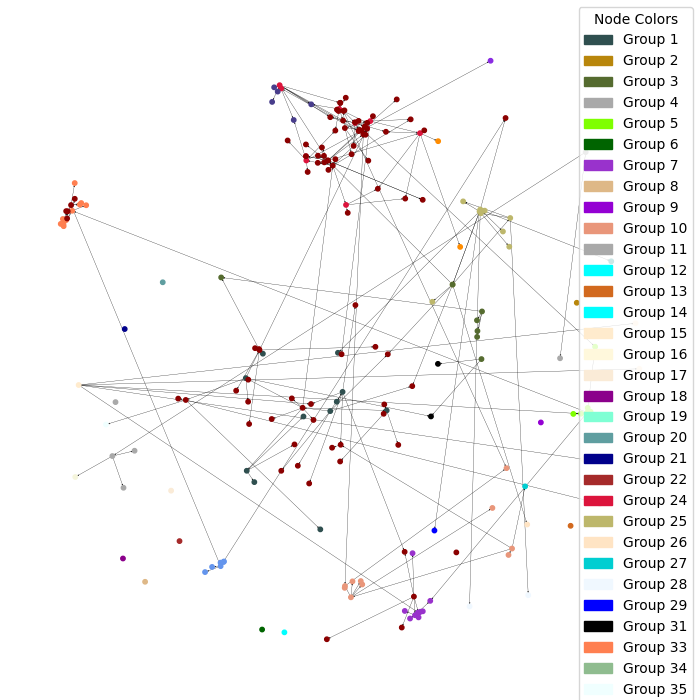

### IncDBSCAN

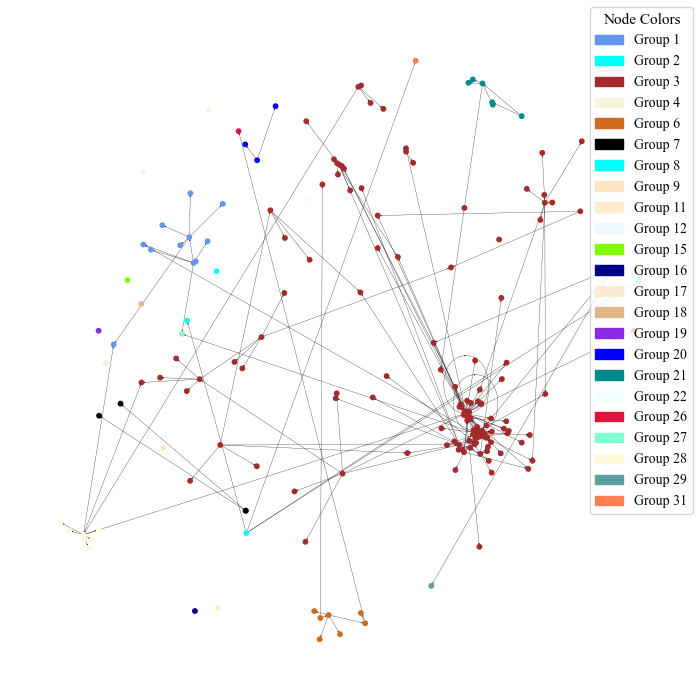

In [4]:
for name, r in results.items():
    display(Markdown(f"### {name}"))
    display(Image(filename=str(r["paths"]["2d_species"]), width=720))

## 3D GDP — MDS × MDS × toxicity

Alive genomes colored by species; archived / noise shown as small dark points. Three orbital views.

### Leader–Follower

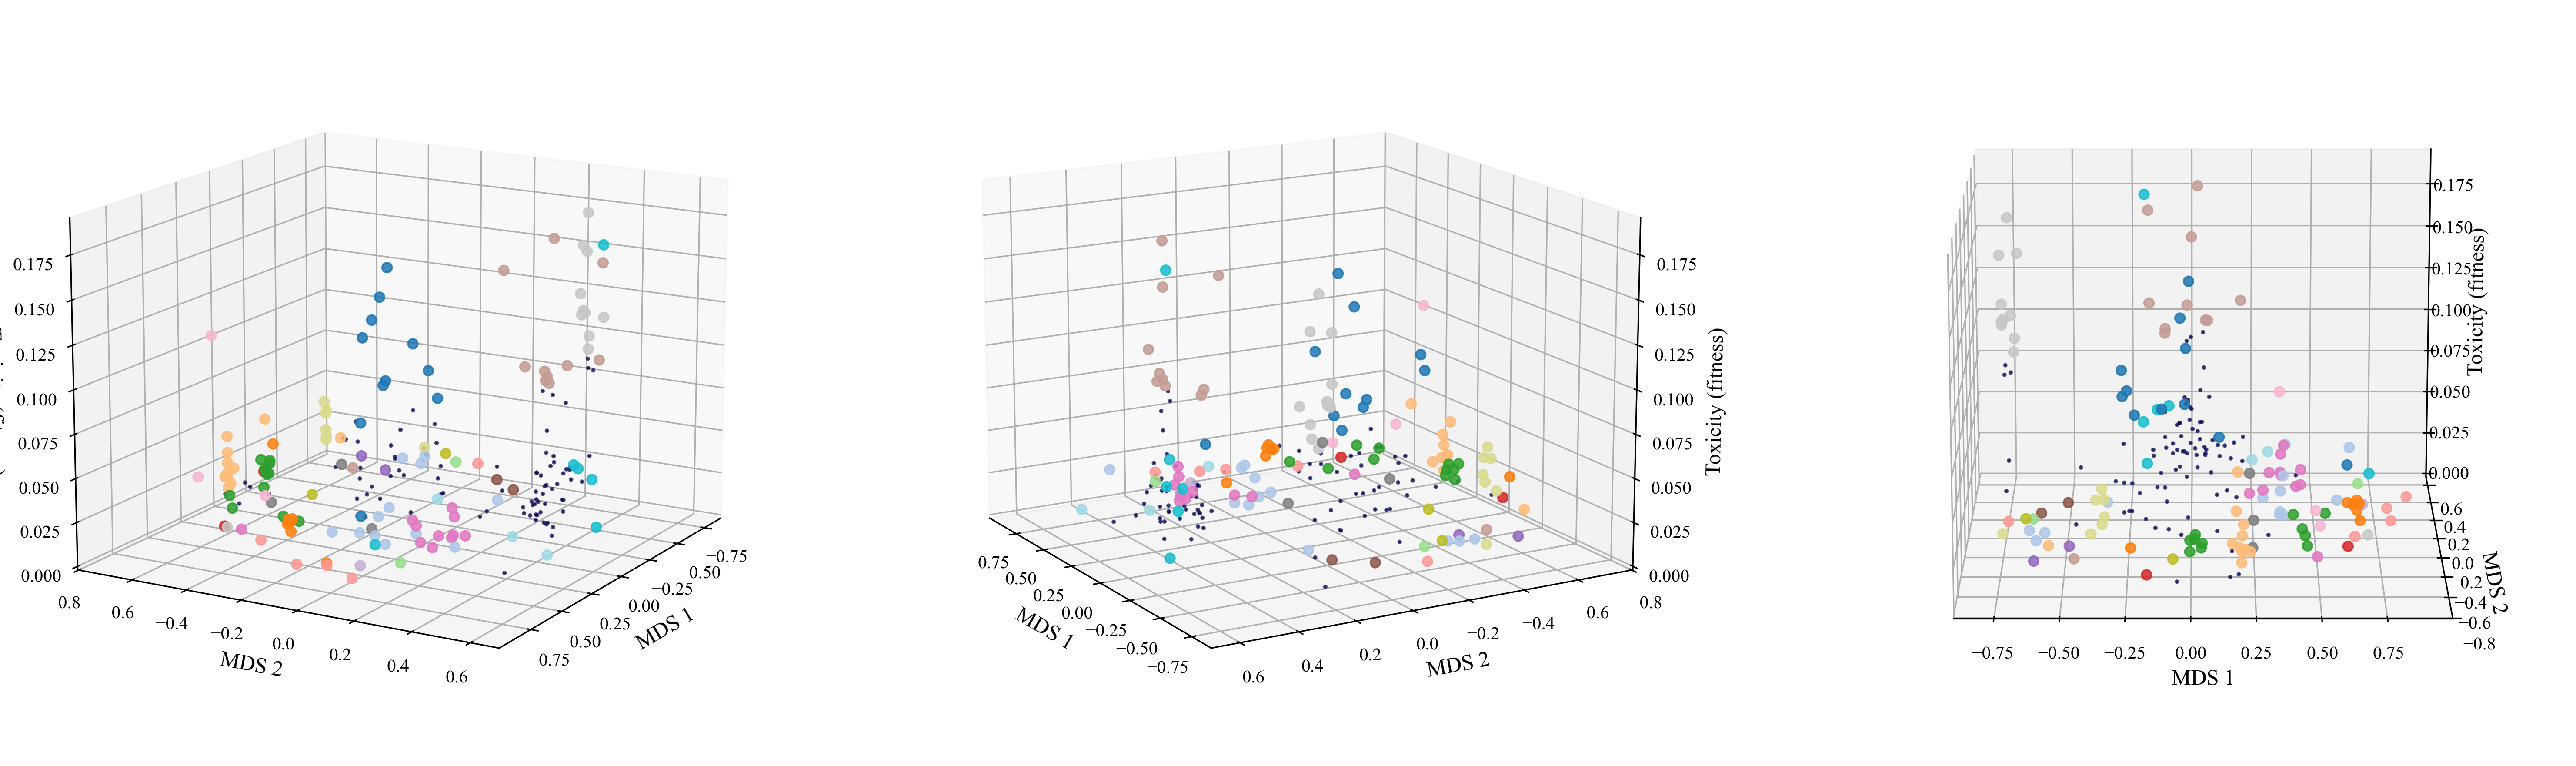

### IncDBSCAN

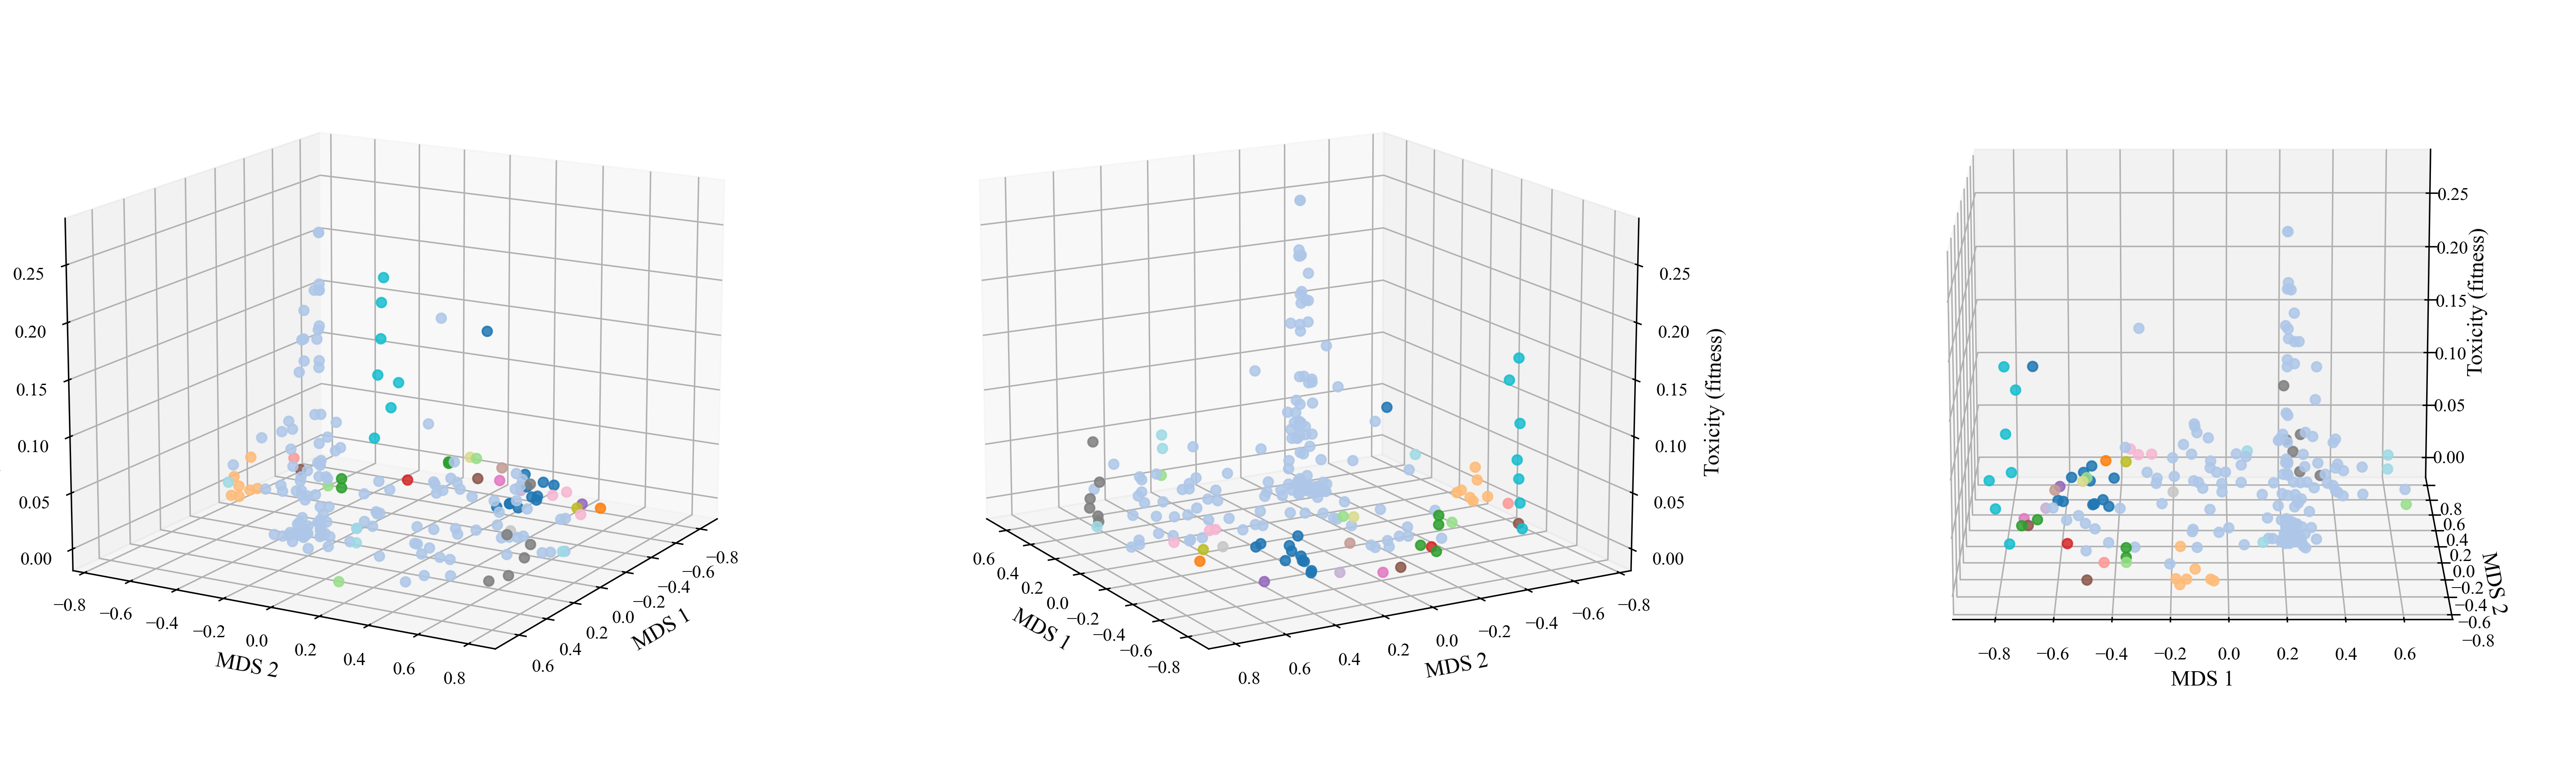

In [5]:
for name, r in results.items():
    display(Markdown(f"### {name}"))
    display(Image(filename=str(r["paths"]["3d_species_archive"]), width=960))

## 3D GDP — MDS × MDS × generation (color = toxicity)

### Leader–Follower

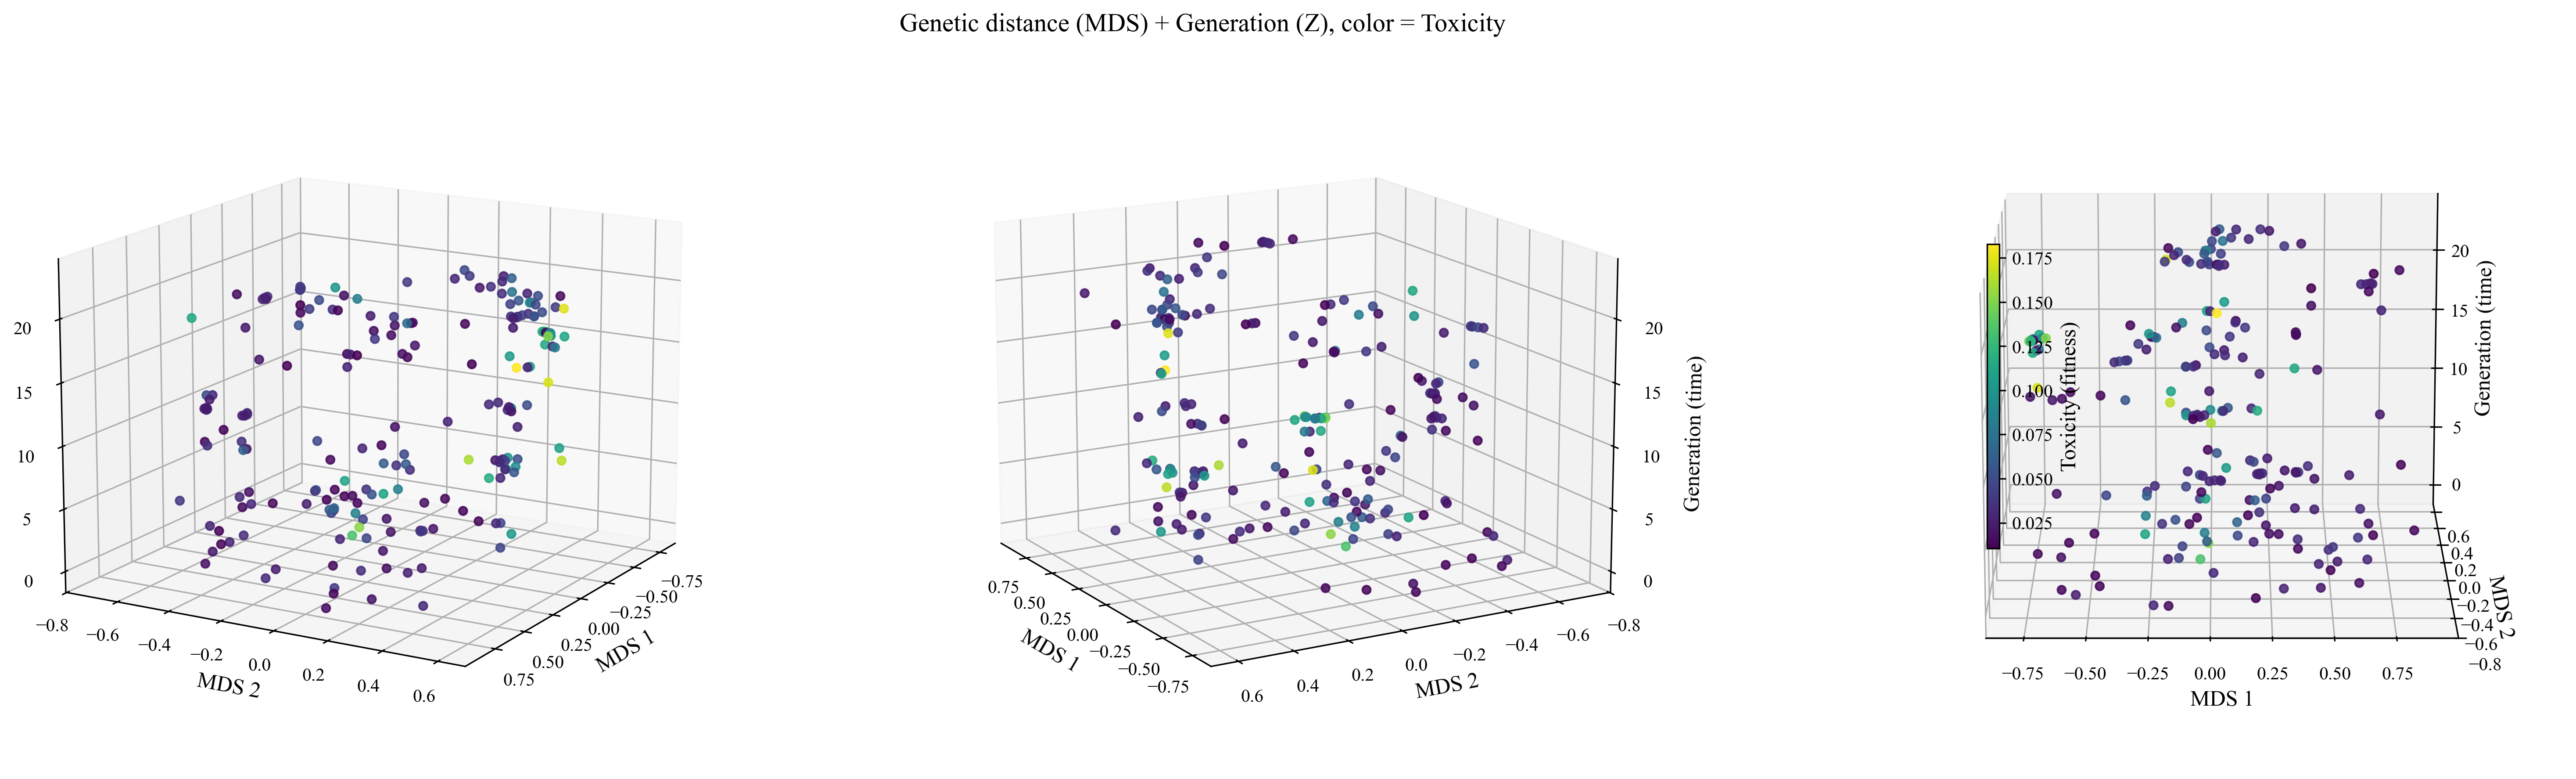

### IncDBSCAN

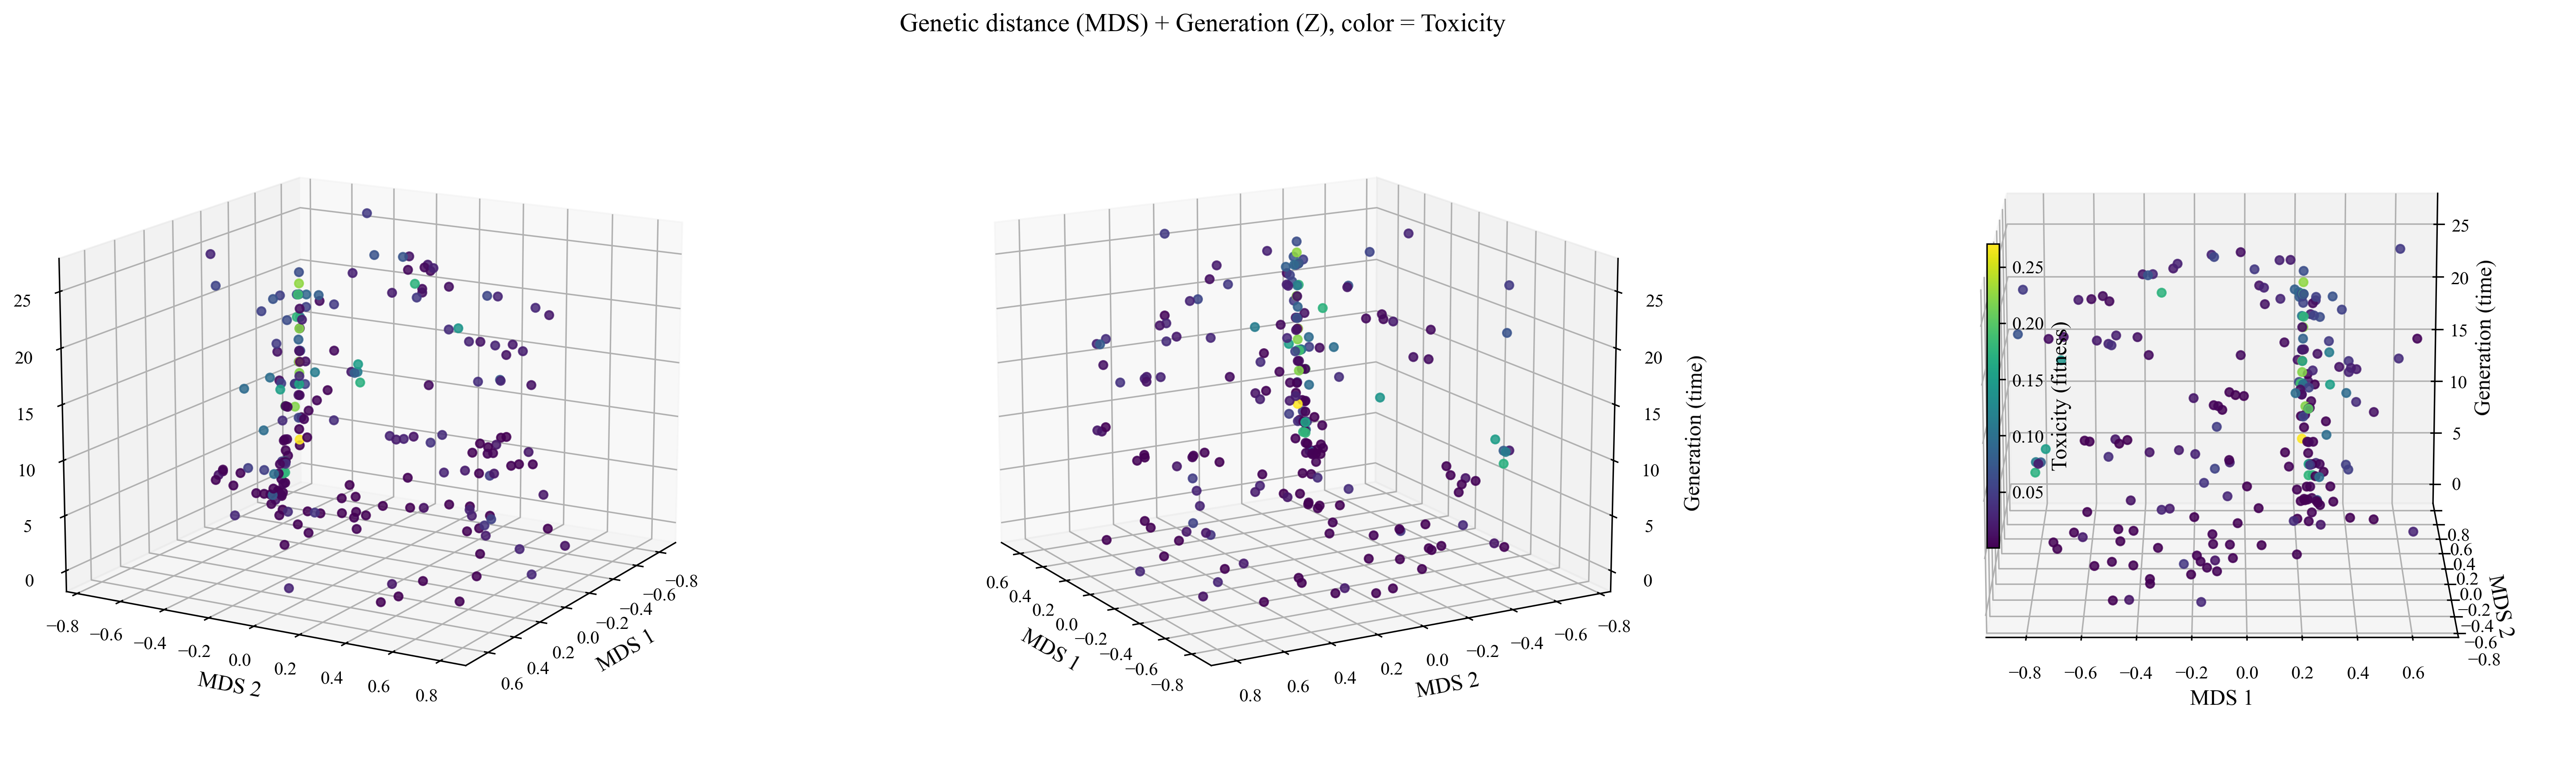

In [6]:
for name, r in results.items():
    display(Markdown(f"### {name}"))
    display(Image(filename=str(r["paths"]["3d_gen_toxicity"]), width=960))

## Side-by-side comparison (static)

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
pairs = [
    ("2d_species", "2D species"),
    ("3d_species_archive", "3D toxicity / species"),
]
row = 0
for key, title in pairs:
    for col, name in enumerate(results):
        ax = axes[row, col]
        img = plt.imread(results[name]["paths"][key])
        ax.imshow(img)
        ax.set_title(f"{name} — {title}")
        ax.axis("off")
    row += 1
plt.tight_layout()
cmp_path = PROJECT_ROOT / "data/outputs/gdp_lf_vs_inc_dbscan_side_by_side.png"
fig.savefig(cmp_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(cmp_path), width=960))
print("Saved", cmp_path)

/var/folders/t8/nrzsz40n223cvd6fg23stq9m0000gn/T/ipykernel_11392/3972074489.py:16: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



## Interactive Plotly (HTML)

Open the HTML files below (or the embedded iframes) to rotate / hover genomes.

In [8]:
for name, r in results.items():
    display(Markdown(
        f"### {name}\n"
        f"- Toxicity Z: `{r['paths']['plotly_toxicity']}`\n"
        f"- Generation Z: `{r['paths']['plotly_generation']}`"
    ))
    display(IFrame(src=r["paths"]["plotly_toxicity"].as_uri(), width="100%", height=720))

### Leader–Follower
- Toxicity Z: `/Users/onkars/Documents/Projects/ToxSearch-S/data/outputs/local_20261007_162107_lf_g210/figures/gdp_notebook/gdp_3d_plotly_toxicity.html`
- Generation Z: `/Users/onkars/Documents/Projects/ToxSearch-S/data/outputs/local_20261007_162107_lf_g210/figures/gdp_notebook/gdp_3d_plotly_generation.html`

/Users/onkars/Documents/Projects/ToxSearch-S/venv/lib/python3.12/site-packages/IPython/core/display.py:447: UserWarning:

Consider using IPython.display.IFrame instead



### IncDBSCAN
- Toxicity Z: `/Users/onkars/Documents/Projects/ToxSearch-S/data/outputs/local_20261007_162107_inc_dbscan_g210/figures/gdp_notebook/gdp_3d_plotly_toxicity.html`
- Generation Z: `/Users/onkars/Documents/Projects/ToxSearch-S/data/outputs/local_20261007_162107_inc_dbscan_g210/figures/gdp_notebook/gdp_3d_plotly_generation.html`

## Notes

- **L–F population**: `elites.json` + `archive.json` (alive = elites).
- **IncDBSCAN population**: `temp.json` density memory \(D_t\) (alive = clustered `density_label` / `species_id` > 0).
- Projection method: cosine-MDS on `prompt_embedding` (384-d).
- Fitness / Z toxicity comes from the active north-star metric (`toxicity` via Perspective scores).